# Ungulate Emotional Valence Classification

Classify emotional valence (positive vs. negative) and species from ungulate contact calls using BEATs and EfficientNet-B0 embeddings.

**Species:** Cow, Pig, Sheep, Goat, Horse, Przewalski's Horse, Wild Boar (7 species, 3,181 calls)

**Dataset:** [Zenodo 14636641](https://zenodo.org/records/14636641) — supplemental data for *Machine Learning Algorithms Can Predict Emotional Valence Across Ungulate Vocalizations*

**Workflow:** download → explore → embed → UMAP → training-free metrics (NMI, ARI, R-AUC) → linear probe → attention probe (sl-BEATs) → static + interactive figures → save artifacts.

In [1]:
import pathlib
import sys


def find_repo_root(start: pathlib.Path) -> pathlib.Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise FileNotFoundError("Could not locate repo root (pyproject.toml not found).")


REPO_ROOT = find_repo_root(pathlib.Path().resolve())
sys.path.insert(0, str(REPO_ROOT))

import json
import urllib.request
import zipfile

import librosa
import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd
import plotly.express as px
import torch
from avex import load_model
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from tqdm.auto import tqdm

from utils.probing import compute_training_free_metrics, run_attention_probe, run_linear_probe
from utils.visualization import (
    confusion_heatmap_static,
    plot_model_comparison,
    plot_model_comparison_static,
    plot_umap,
    plot_umap_static,
)

EXAMPLE_DIR = REPO_ROOT / "examples" / "09_ungulate_valence"
DATA_DIR = EXAMPLE_DIR / "data"
AUDIO_DIR = DATA_DIR / "audio"
META_DIR = DATA_DIR / "metadata"
EMBED_DIR = DATA_DIR / "embeddings"
ARTIFACTS_DIR = EXAMPLE_DIR / "artifacts"
for _d in [AUDIO_DIR, META_DIR, EMBED_DIR, ARTIFACTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16_000
DEVICE = "cpu"
BEATS_MODEL = "esp_aves2_sl_beats_all"
EFFNET_MODEL = "esp_aves2_effnetb0_all"
print("Setup complete.")

2026-04-16 17:21:47.411760: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-04-16 17:21:49.258093: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Setup complete.


## 1. Download Dataset

In [2]:
SOUNDS_URL = "https://zenodo.org/records/14636641/files/SoundsDatabase.zip"
META_URL = "https://zenodo.org/records/14636641/files/Data%20S1.zip"

SOUNDS_ZIP = DATA_DIR / "SoundsDatabase.zip"
META_ZIP = DATA_DIR / "Data_S1.zip"
EXTRACT_SENTINEL = AUDIO_DIR / ".extracted"
META_SENTINEL = META_DIR / ".extracted"


def download_with_progress(url: str, dest: pathlib.Path) -> None:
    def _hook(count: int, block_size: int, total_size: int) -> None:
        if total_size > 0:
            pct = min(count * block_size / total_size * 100, 100)
            print(f"\r  {pct:5.1f}%", end="", flush=True)

    urllib.request.urlretrieve(url, dest, reporthook=_hook)
    print()


if not SOUNDS_ZIP.exists():
    print("Downloading sounds database (~287 MB) ...")
    download_with_progress(SOUNDS_URL, SOUNDS_ZIP)
else:
    print(f"Sounds archive present ({SOUNDS_ZIP.stat().st_size / 1e6:.1f} MB) — skipping.")

if not META_ZIP.exists():
    print("Downloading metadata (~19 KB) ...")
    download_with_progress(META_URL, META_ZIP)
else:
    print(f"Metadata archive present ({META_ZIP.stat().st_size / 1024:.1f} KB) — skipping.")

if not EXTRACT_SENTINEL.exists():
    print("Extracting sounds (may take a moment) ...")
    with zipfile.ZipFile(SOUNDS_ZIP) as zf:
        zf.extractall(AUDIO_DIR)
    EXTRACT_SENTINEL.touch()
    print("Done.")
else:
    print("Sounds already extracted.")

if not META_SENTINEL.exists():
    print("Extracting metadata ...")
    with zipfile.ZipFile(META_ZIP) as zf:
        zf.extractall(META_DIR)
    META_SENTINEL.touch()
    print("Done.")
else:
    print("Metadata already extracted.")

Sounds archive present (286.9 MB) — skipping.
Metadata archive present (18.9 KB) — skipping.
Sounds already extracted.
Metadata already extracted.


## 2. Data Exploration

In [3]:
# Inspect extracted audio directory structure
print("Top-level contents of audio directory:")
for item in sorted(AUDIO_DIR.iterdir()):
    if item.name.startswith("."):
        continue
    if item.is_dir():
        n = sum(1 for _ in item.rglob("*") if _.is_file())
        print(f"  [DIR]  {item.name}/  ({n} files)")
    else:
        print(f"  [FILE] {item.name}")

print("\nMetadata files:")
for f in sorted(META_DIR.rglob("*")):
    if f.is_file() and not f.name.startswith(".") and not f.name.startswith("~"):
        print(f"  {f.relative_to(META_DIR)}  ({f.stat().st_size / 1024:.1f} KB)")

Top-level contents of audio directory:
  [DIR]  SoundsDatabase/  (3181 files)

Metadata files:
  Data S1.xlsx  (21.2 KB)


In [4]:
# Convert raw Excel annotations to CSV in artifacts (once), then always load from there.
# openpyxl is used explicitly here; after this cell openpyxl is no longer needed.
ANNOTATIONS_CSV = ARTIFACTS_DIR / "annotations.csv"

if not ANNOTATIONS_CSV.exists():
    _xlsx_candidates = [
        f for f in META_DIR.rglob("*") if f.suffix.lower() in {".xlsx", ".xls"} and not f.name.startswith((".", "~"))
    ]
    assert _xlsx_candidates, f"No Excel spreadsheet found in {META_DIR}. Run the download cell first."
    _xlsx_path = _xlsx_candidates[0]
    print(f"Converting {_xlsx_path.name} → annotations.csv via openpyxl ...")

    wb = openpyxl.load_workbook(_xlsx_path, read_only=True, data_only=True)
    ws = wb.active
    rows = list(ws.values)
    wb.close()

    _headers = [str(h).strip() if h is not None else f"col_{i}" for i, h in enumerate(rows[0])]
    _data = [list(row) for row in rows[1:] if any(v is not None for v in row)]
    _ann_df = pd.DataFrame(_data, columns=_headers)
    _ann_df.to_csv(ANNOTATIONS_CSV, index=False)
    print(f"Saved {len(_ann_df)} annotation rows → {ANNOTATIONS_CSV.relative_to(EXAMPLE_DIR)}")
else:
    print("annotations.csv already exists — skipping openpyxl conversion.")

# Always load from the CSV copy in artifacts
annotations_df = pd.read_csv(ANNOTATIONS_CSV)
print(f"\nAnnotations shape: {annotations_df.shape}")
print(f"Columns: {list(annotations_df.columns)}")
display(annotations_df.head(10))

annotations.csv already exists — skipping openpyxl conversion.

Annotations shape: (335, 7)
Columns: ['Data S1. Repartition of the calls according to animal identity (ID), species, call type, emotional valence, context of vocal production, and their respective number of occurrences, along with references to original studies. Related to STAR Methods.', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6']


,"Data S1. Repartition of the calls according to animal identity (ID), species, call type, emotional valence, context of vocal production, and their respective number of occurrences, along with references to original studies. Related to STAR Methods.",col_1,col_2,col_3,col_4,col_5,col_6
0,Animal ID,Species,Call type,Valence,Context,Nb of calls,Reference
1,1140,Cow,Low- frequency (closed-mouth) and high-frequen...,Negative,Full (physical and visual) separation from cal...,40,"Padilla de la Torre, M., Hillmann, E., and Bri..."
2,1140,NaN,NaN,Positive,Physical reunion with calf,2,NaN
3,1140,NaN,NaN,Positive,Visual (but not physical) reunion with calf,2,NaN
4,1150,NaN,NaN,Negative,Full (physical and visual) separation from cal...,48,NaN
5,1150,NaN,NaN,Negative,Physical (but not visual) separation from calf,1,NaN
6,1150,NaN,NaN,Positive,Visual (but not physical) reunion with calf,3,NaN
7,1152,NaN,NaN,Negative,Full (physical and visual) separation from cal...,44,NaN
8,1152,NaN,NaN,Positive,Physical reunion with calf,1,NaN
9,1152,NaN,NaN,Positive,Visual (but not physical) reunion with calf,2,NaN


In [5]:
# Collect all audio files
_audio_exts = {".wav", ".mp3", ".flac", ".ogg"}
all_audio_paths = sorted(p for p in AUDIO_DIR.rglob("*") if p.suffix.lower() in _audio_exts)
print(f"Found {len(all_audio_paths)} audio files")
print("\nSample paths (first 5):")
for p in all_audio_paths[:5]:
    print(f"  {p.relative_to(AUDIO_DIR)}")

Found 3181 audio files

Sample paths (first 5):
  SoundsDatabase/1140-Cow-FullSeparation-Negative-1094.wav
  SoundsDatabase/1140-Cow-FullSeparation-Negative-1168.wav
  SoundsDatabase/1140-Cow-FullSeparation-Negative-1185.wav
  SoundsDatabase/1140-Cow-FullSeparation-Negative-1216.wav
  SoundsDatabase/1140-Cow-FullSeparation-Negative-1289.wav


In [6]:
# Extract species and valence labels from path structure
# The dataset encodes labels in folder names or filenames.
_VALENCE_POS = {"positive", "pos"}
_VALENCE_NEG = {"negative", "neg"}
_SPECIES_KEYS = {
    "cow": "Cow",
    "cattle": "Cow",
    "pig": "Pig",
    "sheep": "Sheep",
    "goat": "Goat",
    "horse": "Horse",
    "przewalski": "Przewalski's Horse",
    "boar": "Wild Boar",
    "wildboar": "Wild Boar",
}


def _parse_labels(path: pathlib.Path, base: pathlib.Path) -> dict[str, str | None]:
    """Extract species and valence from file path components."""
    parts = [p.lower().replace(" ", "").replace("-", "").replace("_", "") for p in path.relative_to(base).parts]
    parts_joined = " ".join(parts)

    species = None
    for key, name in _SPECIES_KEYS.items():
        if key in parts_joined:
            species = name
            break

    valence = None
    for part in parts:
        if any(kw in part for kw in _VALENCE_POS):
            valence = "positive"
            break
        if any(kw in part for kw in _VALENCE_NEG):
            valence = "negative"
            break

    return {"species": species, "valence": valence}


records = []
for p in all_audio_paths:
    labels = _parse_labels(p, AUDIO_DIR)
    records.append({"path": str(p), **labels})

df = pd.DataFrame(records)

# Report any unresolved labels
_missing_species = df["species"].isna().sum()
_missing_valence = df["valence"].isna().sum()
if _missing_species > 0:
    print(f"WARNING: {_missing_species} files with unknown species. Sample paths:")
    display(df[df["species"].isna()]["path"].head(5))
if _missing_valence > 0:
    print(f"WARNING: {_missing_valence} files with unknown valence. Sample paths:")
    display(df[df["valence"].isna()]["path"].head(5))

# Drop rows where labels could not be resolved
df = df.dropna(subset=["species", "valence"]).reset_index(drop=True)

META_PATH = DATA_DIR / "metadata.csv"
df.to_csv(META_PATH, index=False)
print(f"\nWorking set: {len(df)} calls")
print(f"  Species: {sorted(df['species'].unique())}")
print(f"  Valence: {sorted(df['valence'].unique())}")
display(df.groupby(["species", "valence"]).size().rename("n_calls").unstack(fill_value=0))


Working set: 3181 calls
  Species: ['Cow', 'Goat', 'Horse', 'Pig', 'Sheep', 'Wild Boar']
  Valence: ['negative', 'positive']


valence,negative,positive
species,,
Cow,1179,75
Goat,268,93
Horse,245,99
Pig,316,248
Sheep,342,54
Wild Boar,158,104


In [7]:
# Distribution: calls per species coloured by valence
count_df = df.groupby(["species", "valence"]).size().reset_index(name="n_calls").sort_values("species")
fig_dist = px.bar(
    count_df,
    x="species",
    y="n_calls",
    color="valence",
    color_discrete_map={"positive": "#2ecc71", "negative": "#e74c3c"},
    barmode="group",
    title="Calls per species and emotional valence",
    labels={"species": "Species", "n_calls": "Number of calls", "valence": "Valence"},
    text="n_calls",
)
fig_dist.update_traces(textposition="outside")
fig_dist.show()

## 3. Embedding Extraction

In [8]:
MIN_SAMPLES = int(0.5 * TARGET_SR)


def load_audio(path: str, target_sr: int = TARGET_SR) -> torch.Tensor:
    """Load any audio file, convert to mono, resample, zero-pad to at least 0.5 s."""
    # librosa handles WAV, MP3, FLAC, OGG, etc.
    wav, _ = librosa.load(path, sr=target_sr, mono=True)
    if len(wav) < MIN_SAMPLES:
        wav = np.pad(wav, (0, MIN_SAMPLES - len(wav)))
    return torch.from_numpy(wav).unsqueeze(0)


print(f"Sample shape: {load_audio(df['path'].iloc[0]).shape}")

Sample shape: torch.Size([1, 24957])


In [9]:
BEATS_CACHE = EMBED_DIR / "beats_embeddings.npy"

if BEATS_CACHE.exists() and np.load(BEATS_CACHE).shape[0] == len(df):
    beats_embs = np.load(BEATS_CACHE)
    print(f"Loaded cached BEATs last-layer embeddings: {beats_embs.shape}")
else:
    print(f"Loading model: {BEATS_MODEL}")
    model = load_model(BEATS_MODEL, return_features_only=True, device=DEVICE)
    model.eval()
    embeddings = []
    with torch.no_grad():
        for path in tqdm(df["path"], desc="BEATs last-layer"):
            wav = load_audio(path)
            feats = model(wav)  # (1, T, 768)
            embeddings.append(feats.mean(dim=1).squeeze(0).cpu().numpy())
    beats_embs = np.stack(embeddings)
    np.save(BEATS_CACHE, beats_embs)
    print(f"Saved BEATs last-layer embeddings: {beats_embs.shape}")
    del model

Loaded cached BEATs last-layer embeddings: (3181, 768)


In [10]:
BEATS_ALL_CACHE = EMBED_DIR / "beats_all_layers_embeddings.npy"

if BEATS_ALL_CACHE.exists() and np.load(BEATS_ALL_CACHE).shape[0] == len(df):
    beats_all_embs = np.load(BEATS_ALL_CACHE)
    print(f"Loaded cached BEATs all-layers embeddings: {beats_all_embs.shape}")
else:
    print(f"Loading model for all-layers extraction: {BEATS_MODEL}")
    model = load_model(BEATS_MODEL, return_features_only=True, device=DEVICE)
    model.eval()

    try:
        encoder_layers = model.model.encoder.layers
    except AttributeError:
        encoder_layers = model.backbone.encoder.layers
    n_layers = len(encoder_layers)
    layer_store: dict = {}
    hooks = []
    for i, layer in enumerate(encoder_layers):

        def _make_hook(idx: int):
            def _hook(module, inp, out):
                layer_store[idx] = out[0] if isinstance(out, tuple) else out

            return _hook

        hooks.append(layer.register_forward_hook(_make_hook(i)))
    print(f"  Registered hooks on {n_layers} transformer layers.")

    all_embs = []
    with torch.no_grad():
        for path in tqdm(df["path"], desc="BEATs all-layers"):
            layer_store.clear()
            wav = load_audio(path)
            _ = model(wav)
            per_layer = [
                layer_store[i].view(-1, layer_store[i].shape[-1]).mean(dim=0).cpu().numpy() for i in range(n_layers)
            ]
            all_embs.append(np.mean(per_layer, axis=0))

    for h in hooks:
        h.remove()

    beats_all_embs = np.stack(all_embs)
    np.save(BEATS_ALL_CACHE, beats_all_embs)
    print(f"Saved BEATs all-layers embeddings: {beats_all_embs.shape}")
    del model

Loaded cached BEATs all-layers embeddings: (3181, 768)


In [11]:
EFFNET_CACHE = EMBED_DIR / "effnet_embeddings.npy"

if EFFNET_CACHE.exists() and np.load(EFFNET_CACHE).shape[0] == len(df):
    effnet_embs = np.load(EFFNET_CACHE)
    print(f"Loaded cached EfficientNet embeddings: {effnet_embs.shape}")
else:
    print(f"Loading model: {EFFNET_MODEL}")
    model = load_model(EFFNET_MODEL, return_features_only=True, device=DEVICE)
    model.eval()
    embeddings = []
    with torch.no_grad():
        for path in tqdm(df["path"], desc="EfficientNet"):
            wav = load_audio(path)
            feats = model(wav)  # (1, C, H, W)
            embeddings.append(feats.mean(dim=(2, 3)).squeeze(0).cpu().numpy())
    effnet_embs = np.stack(embeddings)
    np.save(EFFNET_CACHE, effnet_embs)
    print(f"Saved EfficientNet embeddings: {effnet_embs.shape}")
    del model

Loaded cached EfficientNet embeddings: (3181, 1280)


## 4. UMAP Visualisation

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


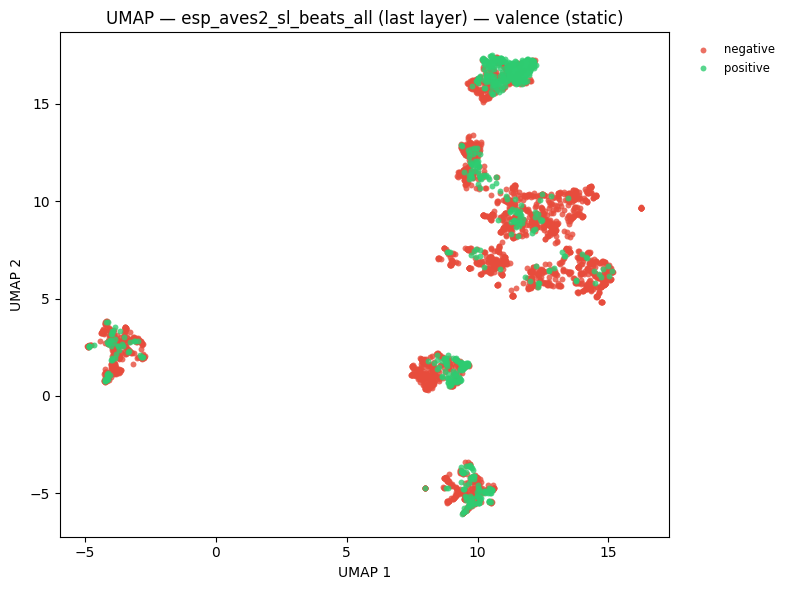

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


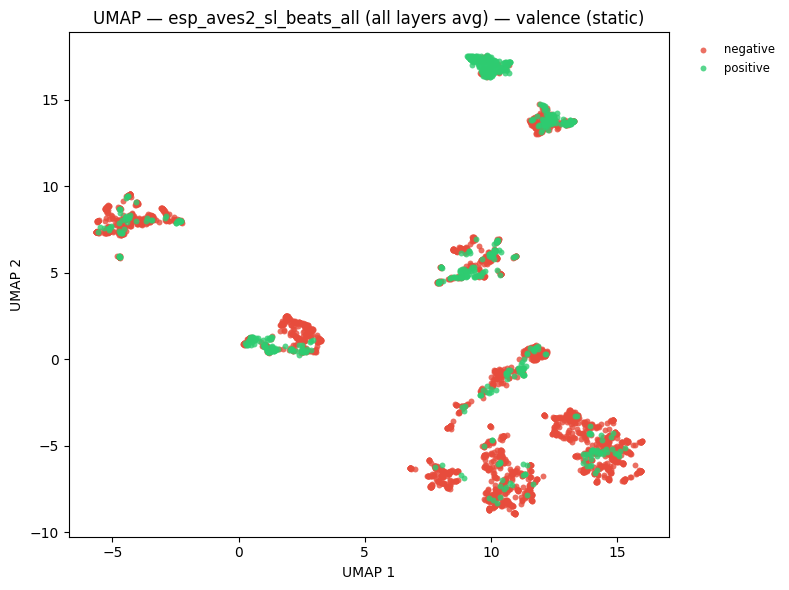

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


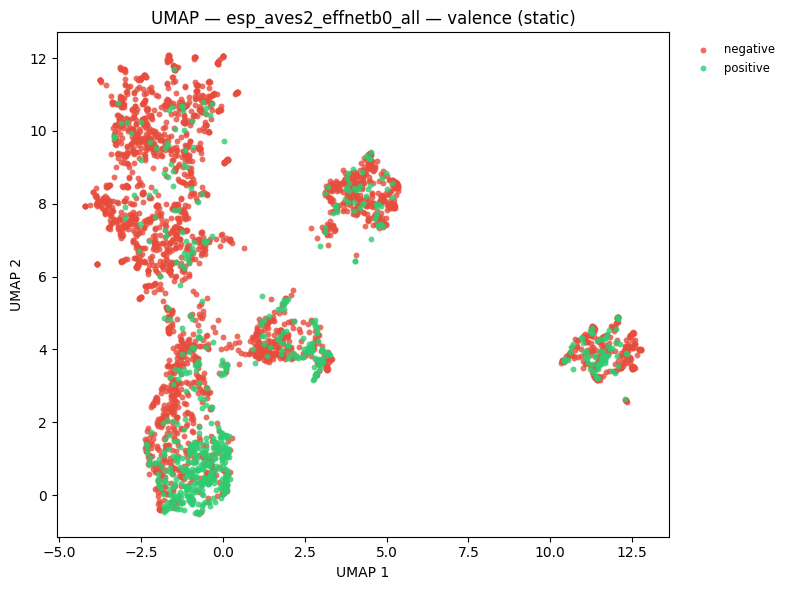

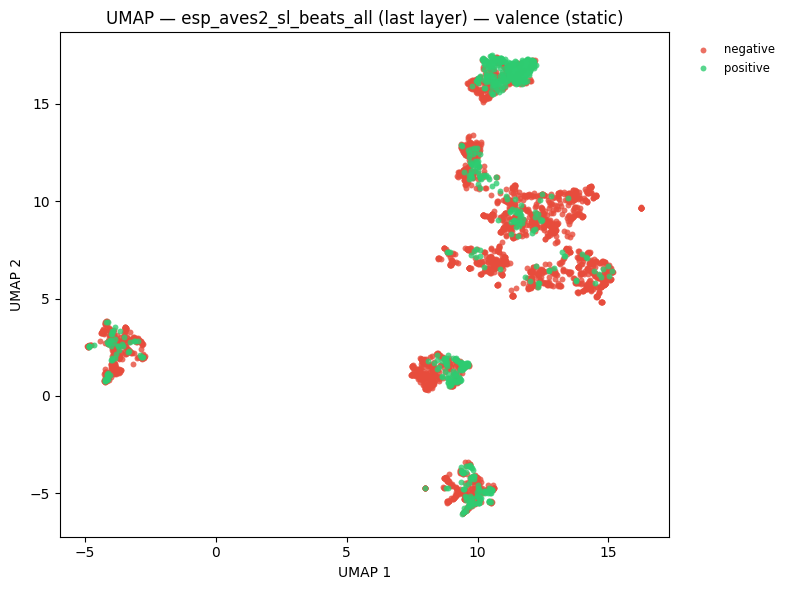

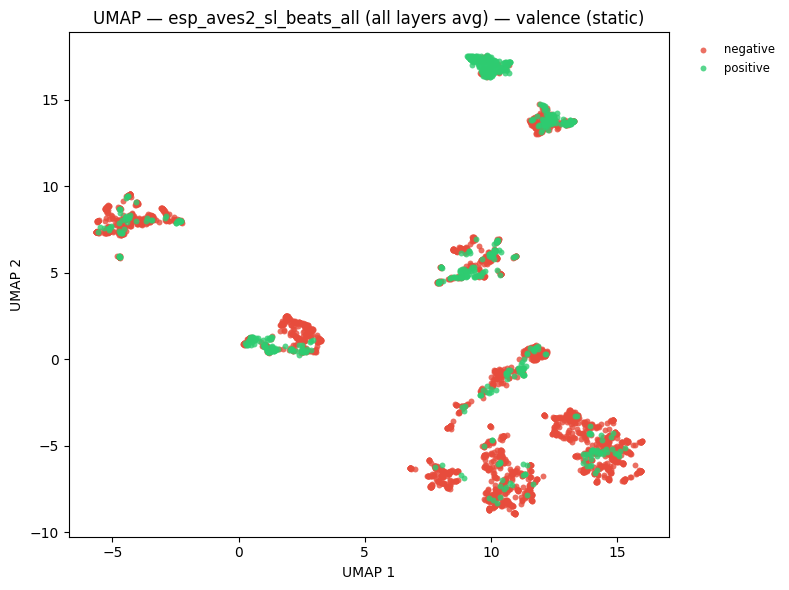

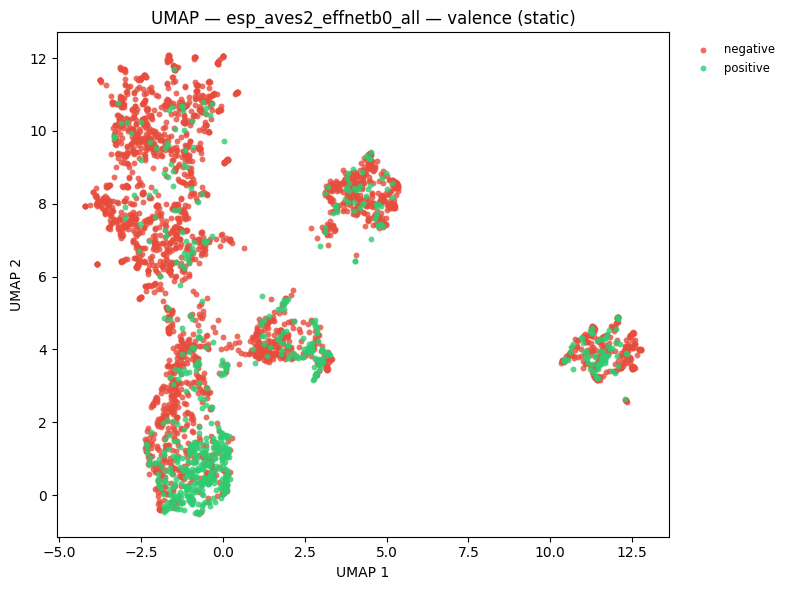

In [12]:
valence_labels = df["valence"].tolist()
species_labels = df["species"].tolist()
hover = [f"{sp} ({v})" for sp, v in zip(species_labels, valence_labels, strict=False)]

VALENCE_COLOR_MAP = {"positive": "#2ecc71", "negative": "#e74c3c"}

_unique_species = sorted(set(species_labels))
_sp_palette = px.colors.qualitative.Dark24
SPECIES_COLOR_MAP = {sp: _sp_palette[i % len(_sp_palette)] for i, sp in enumerate(_unique_species)}

_model_embs = [
    (f"{BEATS_MODEL} (last layer)", beats_embs),
    (f"{BEATS_MODEL} (all layers avg)", beats_all_embs),
    (EFFNET_MODEL, effnet_embs),
]

# UMAP coloured by emotional valence
umap_valence_figs = {}
umap_valence_static_figs = {}
for name, embs in _model_embs:
    fig = plot_umap(
        embs,
        labels=valence_labels,
        title=f"UMAP — {name}<br><sup>colour = emotional valence</sup>",
        hover_text=hover,
        color_discrete_map=VALENCE_COLOR_MAP,
    )
    umap_valence_figs[name] = fig
    fig.show()
    static = plot_umap_static(
        embs,
        labels=valence_labels,
        title=f"UMAP — {name} — valence (static)",
        color_map=VALENCE_COLOR_MAP,
    )
    umap_valence_static_figs[name] = static
    display(static)

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


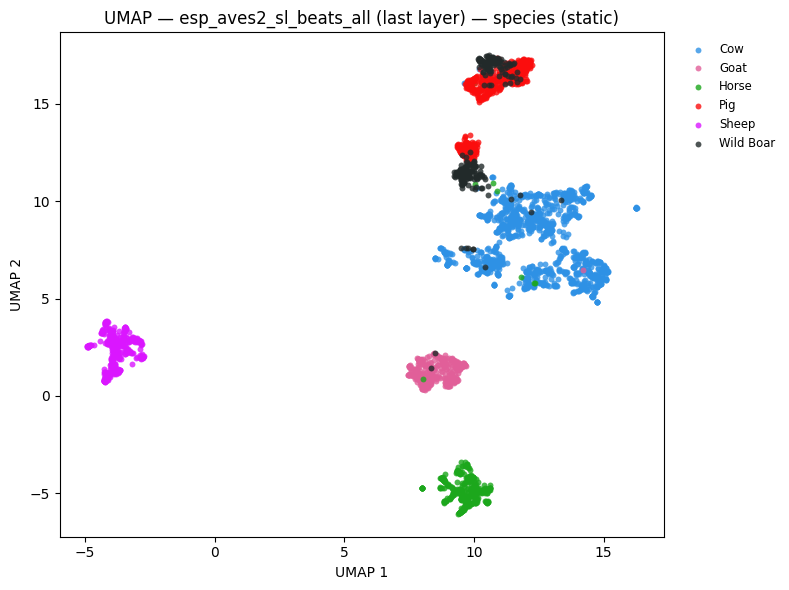

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


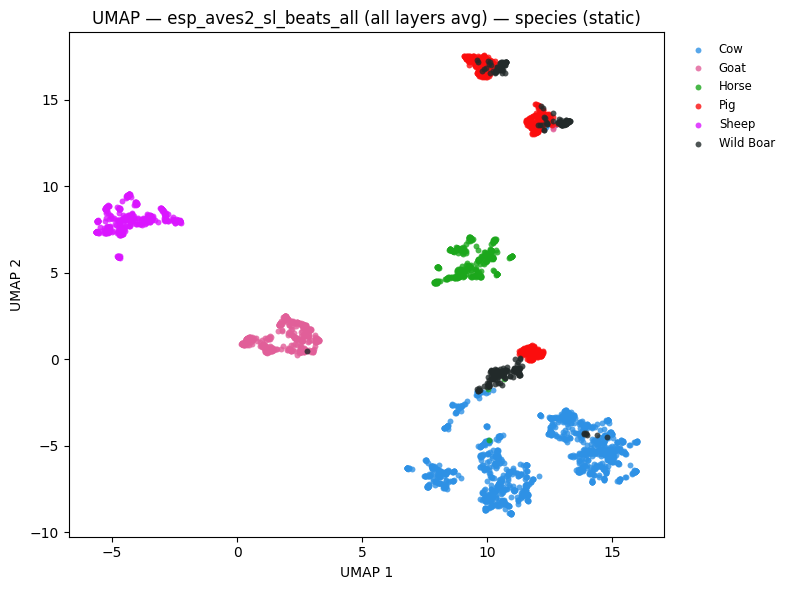

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


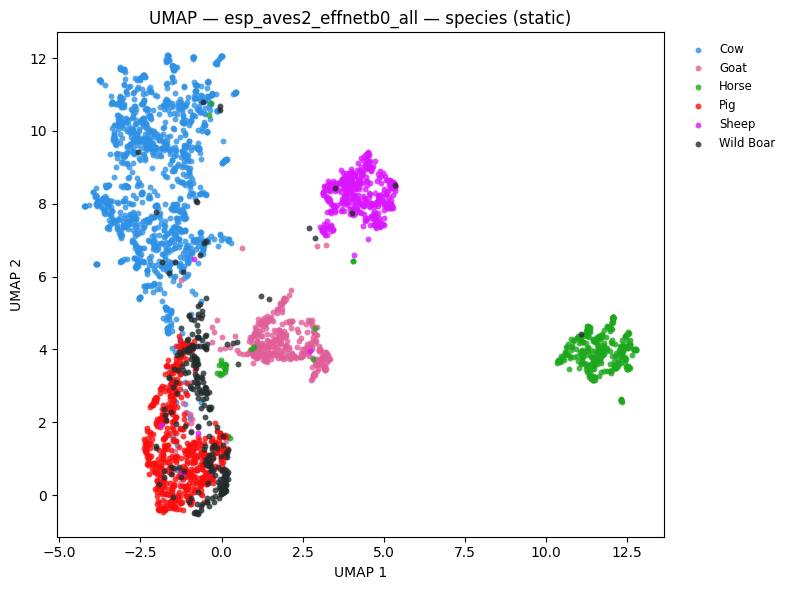

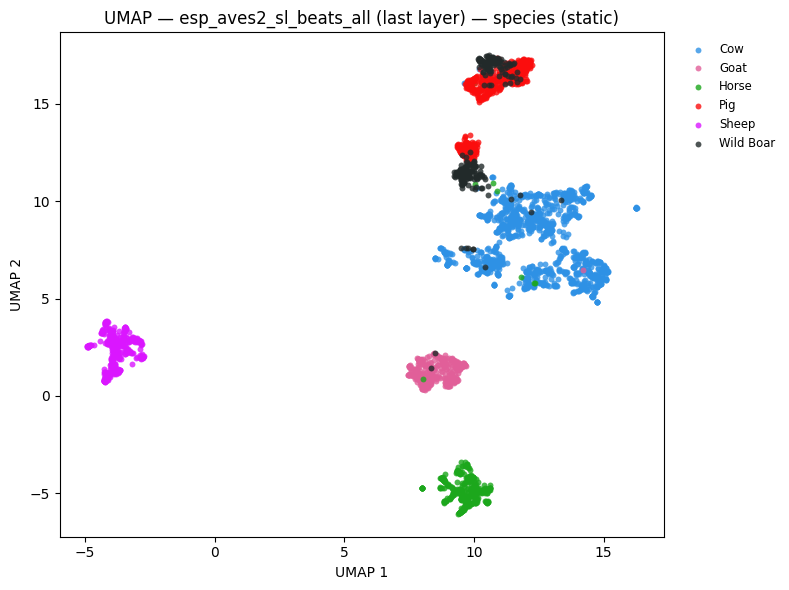

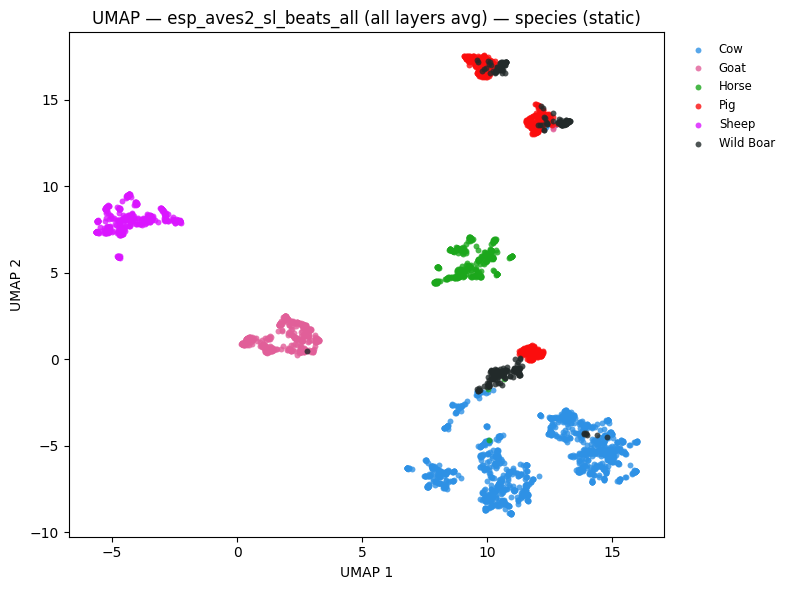

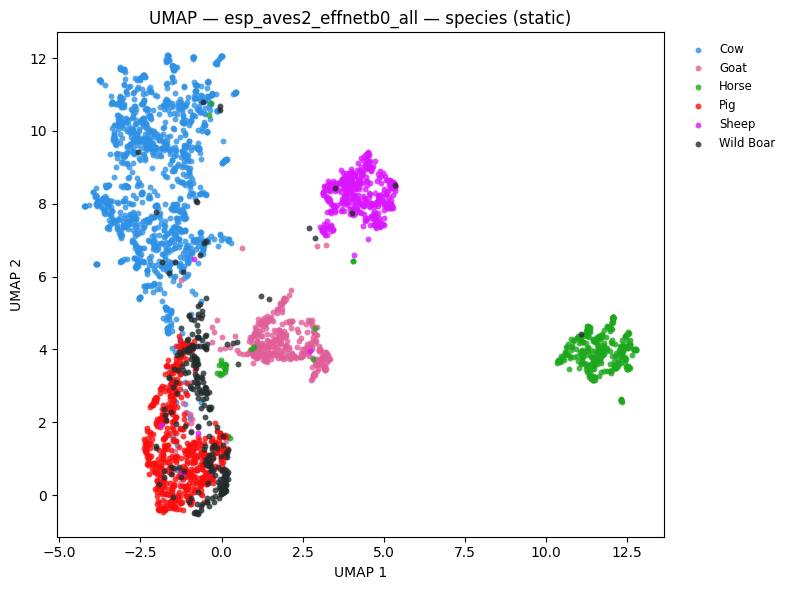

In [13]:
# UMAP coloured by species
umap_species_figs = {}
umap_species_static_figs = {}
for name, embs in _model_embs:
    fig = plot_umap(
        embs,
        labels=species_labels,
        title=f"UMAP — {name}<br><sup>colour = species</sup>",
        hover_text=hover,
        color_discrete_map=SPECIES_COLOR_MAP,
    )
    umap_species_figs[name] = fig
    fig.show()
    static = plot_umap_static(
        embs,
        labels=species_labels,
        title=f"UMAP — {name} — species (static)",
        color_map=SPECIES_COLOR_MAP,
    )
    umap_species_static_figs[name] = static
    display(static)

## 5. Training-Free Metrics

NMI, ARI, and R-AUC evaluate embedding quality without fitting any classifier.

In [14]:
tf_results = {}
for task_name, task_labels in [("valence", valence_labels), ("species", species_labels)]:
    print(f"\n--- Task: {task_name} ---")
    for name, embs in _model_embs:
        m = compute_training_free_metrics(embs, task_labels)
        key = f"{name} | {task_name}"
        tf_results[key] = m
        print(f"  {name}: NMI={m['nmi']:.3f}  ARI={m['ari']:.3f}  R-AUC={m['r_auc']:.3f}")

_tf_rows = [
    {
        "Model": k.split(" | ")[0],
        "Task": k.split(" | ")[1],
        "NMI": round(v["nmi"], 3),
        "ARI": round(v["ari"], 3),
        "R-AUC": round(v["r_auc"], 3),
    }
    for k, v in tf_results.items()
]
display(pd.DataFrame(_tf_rows).set_index(["Model", "Task"]))


--- Task: valence ---


  esp_aves2_sl_beats_all (last layer): NMI=0.092  ARI=0.213  R-AUC=0.725


  esp_aves2_sl_beats_all (all layers avg): NMI=0.131  ARI=0.278  R-AUC=0.740


  esp_aves2_effnetb0_all: NMI=0.099  ARI=0.189  R-AUC=0.707

--- Task: species ---


  esp_aves2_sl_beats_all (last layer): NMI=0.785  ARI=0.641  R-AUC=0.785


  esp_aves2_sl_beats_all (all layers avg): NMI=0.751  ARI=0.680  R-AUC=0.797


  esp_aves2_effnetb0_all: NMI=0.581  ARI=0.446  R-AUC=0.674


,,NMI,ARI,R-AUC
Model,Task,,,
esp_aves2_sl_beats_all (last layer),valence,0.092,0.213,0.725
esp_aves2_sl_beats_all (all layers avg),valence,0.131,0.278,0.740
esp_aves2_effnetb0_all,valence,0.099,0.189,0.707
esp_aves2_sl_beats_all (last layer),species,0.785,0.641,0.785
esp_aves2_sl_beats_all (all layers avg),species,0.751,0.680,0.797
esp_aves2_effnetb0_all,species,0.581,0.446,0.674


## 6. Linear Probe

Two tasks: binary emotional valence (positive / negative) and 7-class species identification.

In [15]:
probe_kwargs = dict(test_size=0.2, random_state=42, max_iter=1000)

probe_results = {}
for emb_name, embs in _model_embs:
    for task, task_labels in [("valence", valence_labels), ("species", species_labels)]:
        key = f"{emb_name} | {task}"
        res = run_linear_probe(embs, task_labels, **probe_kwargs)
        probe_results[key] = res
        print(f"{key}: accuracy = {res['accuracy']:.3f}")

esp_aves2_sl_beats_all (last layer) | valence: accuracy = 0.750


esp_aves2_sl_beats_all (last layer) | species: accuracy = 0.992


esp_aves2_sl_beats_all (all layers avg) | valence: accuracy = 0.725


esp_aves2_sl_beats_all (all layers avg) | species: accuracy = 0.998


esp_aves2_effnetb0_all | valence: accuracy = 0.759


esp_aves2_effnetb0_all | species: accuracy = 0.979


Task,species,valence
Model,,
esp_aves2_effnetb0_all,0.9790,0.7586
esp_aves2_sl_beats_all (all layers avg),0.9975,0.7254
esp_aves2_sl_beats_all (last layer),0.9917,0.7497


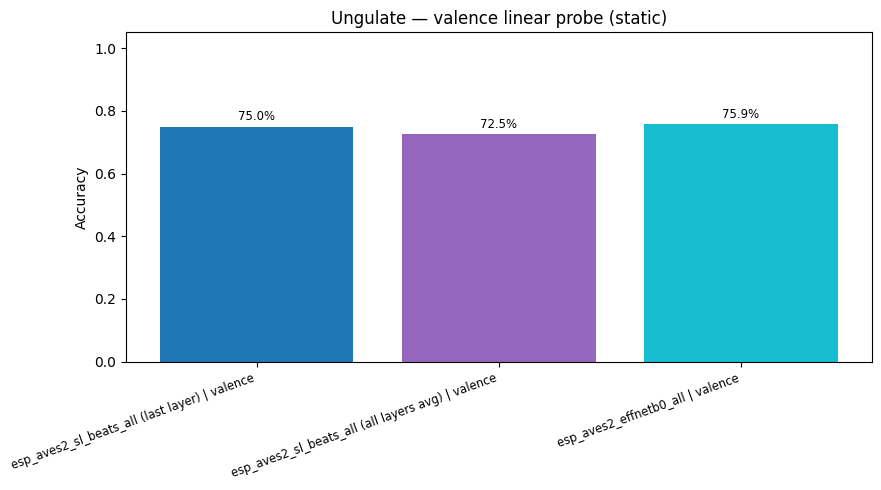

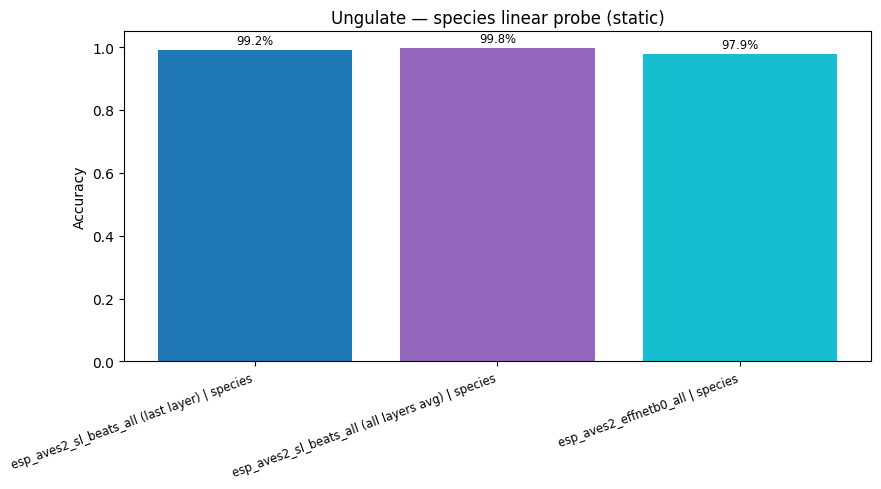

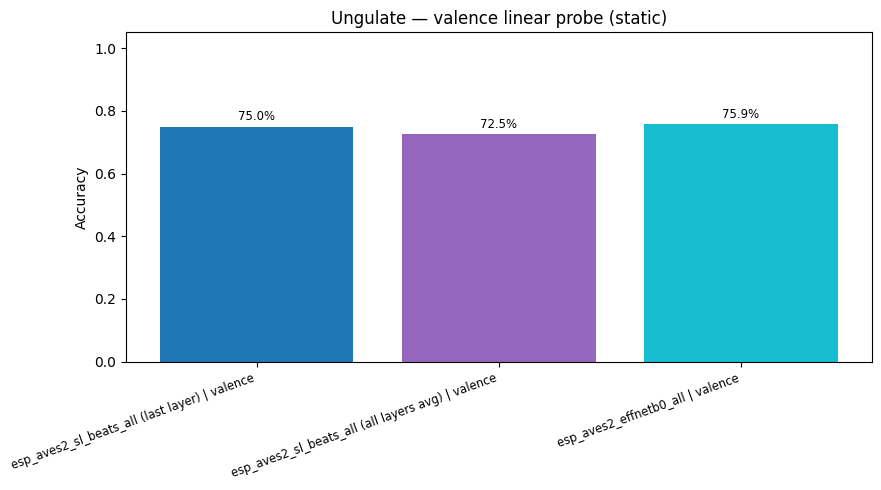

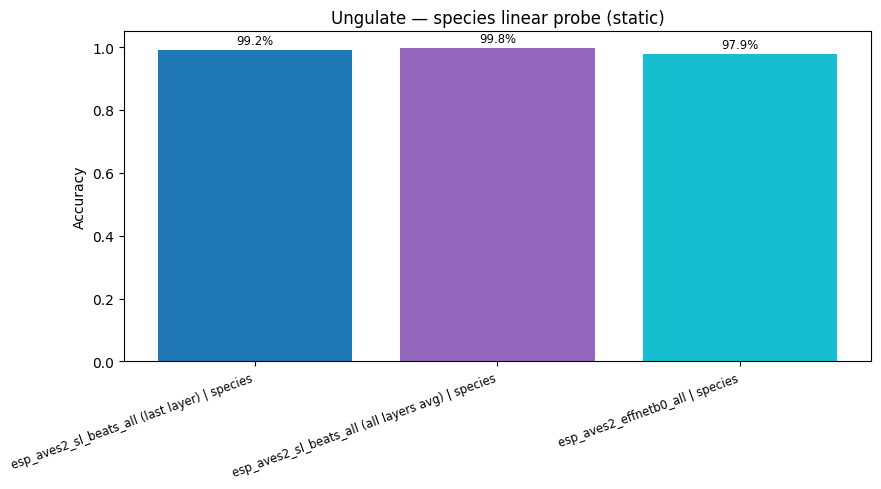

In [16]:
rows = [
    {"Model": k.split(" | ")[0], "Task": k.split(" | ")[1], "Accuracy": round(v["accuracy"], 4)}
    for k, v in probe_results.items()
]
acc_df = pd.DataFrame(rows)
display(acc_df.pivot(index="Model", columns="Task", values="Accuracy").style.format("{:.4f}"))

fig_cmp_valence = plot_model_comparison(
    {k: v["accuracy"] for k, v in probe_results.items() if "valence" in k},
    title="Ungulate — emotional valence classification accuracy",
)
fig_cmp_valence.show()
display(
    plot_model_comparison_static(
        {k: v["accuracy"] for k, v in probe_results.items() if "valence" in k},
        title="Ungulate — valence linear probe (static)",
    )
)

fig_cmp_species = plot_model_comparison(
    {k: v["accuracy"] for k, v in probe_results.items() if "species" in k},
    title="Ungulate — species identification accuracy",
)
fig_cmp_species.show()
display(
    plot_model_comparison_static(
        {k: v["accuracy"] for k, v in probe_results.items() if "species" in k},
        title="Ungulate — species linear probe (static)",
    )
)

## 7. Attention Probe (sl-BEATs)

Multi-head attention probe on BEATs embeddings for both classification tasks.

esp_aves2_sl_beats_all (last layer) | valence (attention): accuracy = 0.762


esp_aves2_sl_beats_all (last layer) | species (attention): accuracy = 0.986


esp_aves2_sl_beats_all (all layers avg) | valence (attention): accuracy = 0.757


esp_aves2_sl_beats_all (all layers avg) | species (attention): accuracy = 0.988


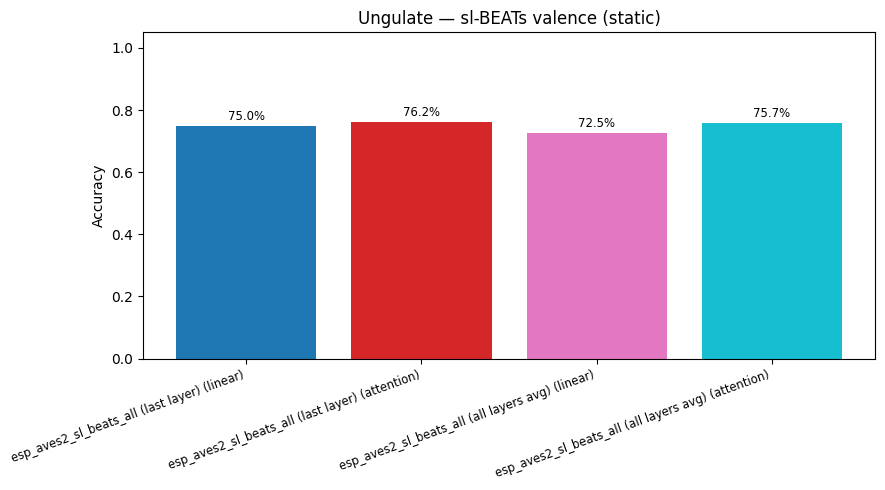

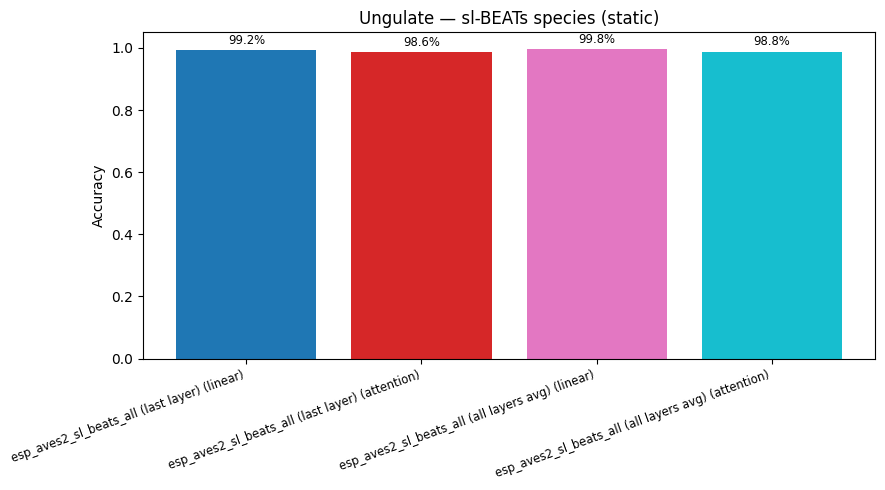

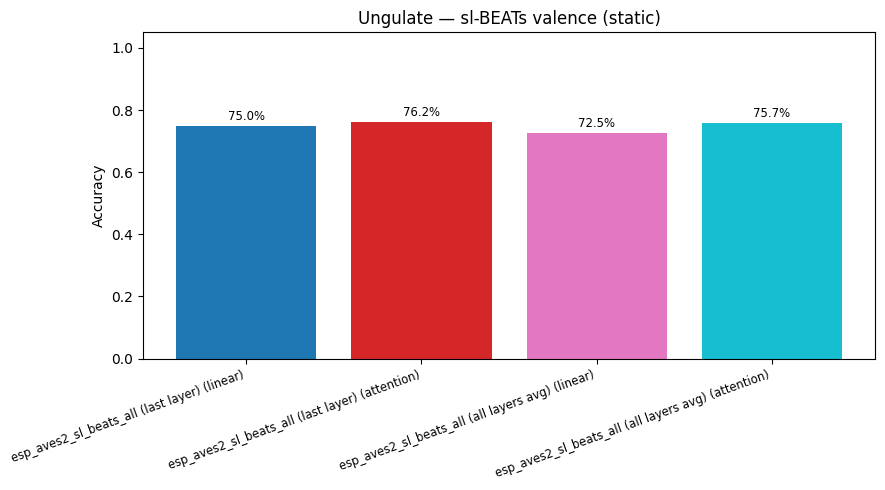

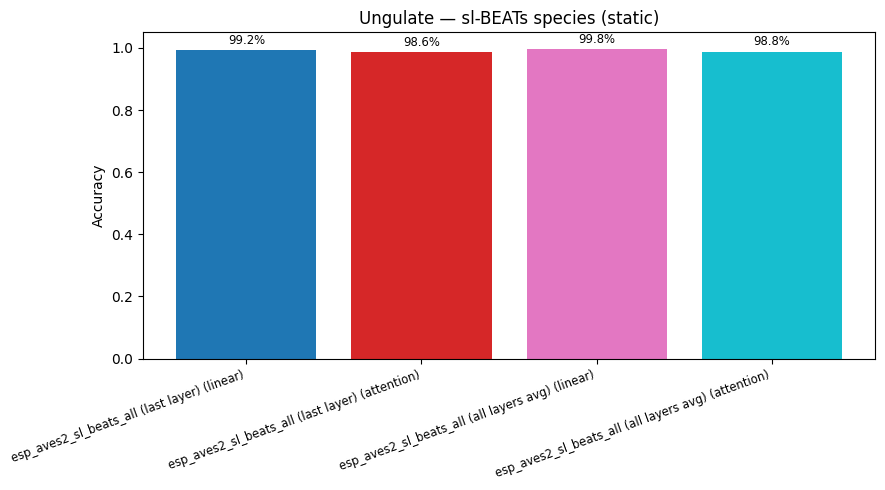

In [17]:
attn_probe_kwargs = dict(num_heads=8, num_attn_layers=2, epochs=50, test_size=0.2, random_state=42)
attention_results = {}
for emb_name, embs in [
    (f"{BEATS_MODEL} (last layer)", beats_embs),
    (f"{BEATS_MODEL} (all layers avg)", beats_all_embs),
]:
    for task, task_labels in [("valence", valence_labels), ("species", species_labels)]:
        key = f"{emb_name} | {task}"
        res = run_attention_probe(embs, task_labels, **attn_probe_kwargs)
        attention_results[key] = res
        print(f"{key} (attention): accuracy = {res['accuracy']:.3f}")

for task in ["valence", "species"]:
    cmp = {}
    for base in [f"{BEATS_MODEL} (last layer)", f"{BEATS_MODEL} (all layers avg)"]:
        k = f"{base} | {task}"
        cmp[f"{base} (linear)"] = probe_results[k]["accuracy"]
        cmp[f"{base} (attention)"] = attention_results[k]["accuracy"]
    fig_attn = plot_model_comparison(cmp, title=f"Ungulate — sl-BEATs {task}: linear vs attention")
    fig_attn.show()
    display(plot_model_comparison_static(cmp, title=f"Ungulate — sl-BEATs {task} (static)"))

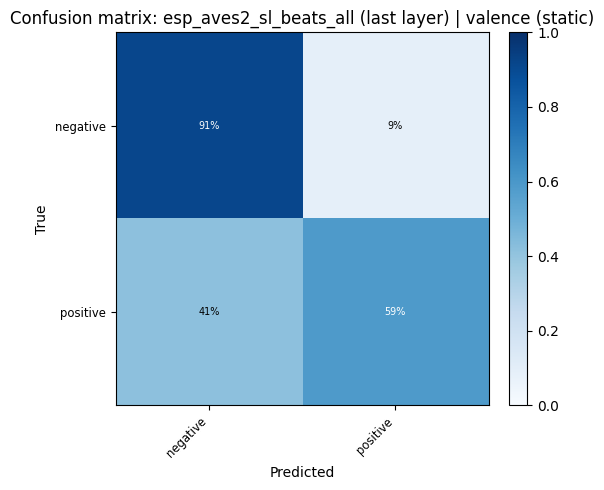

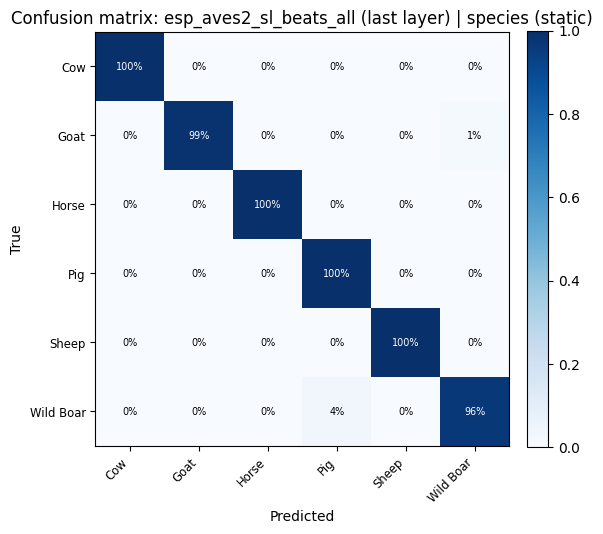

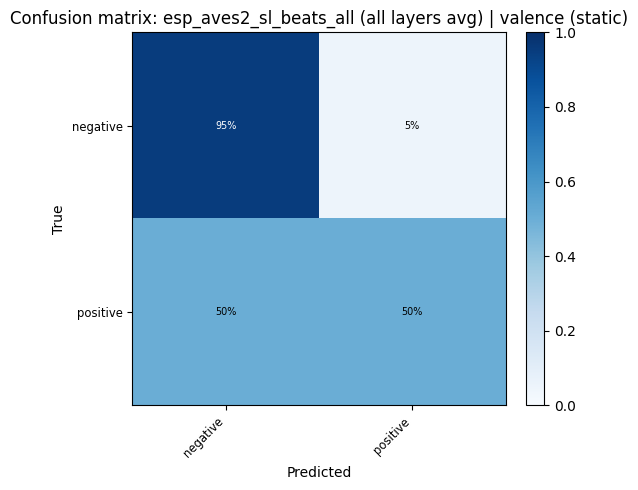

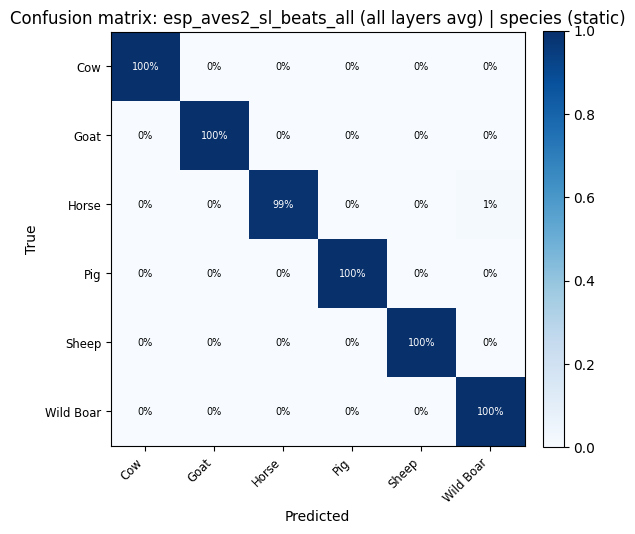

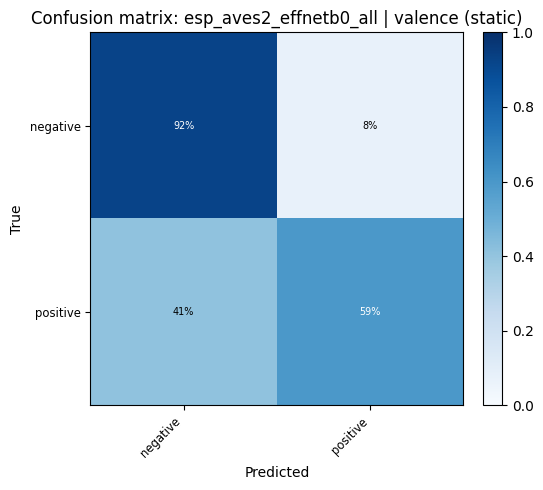

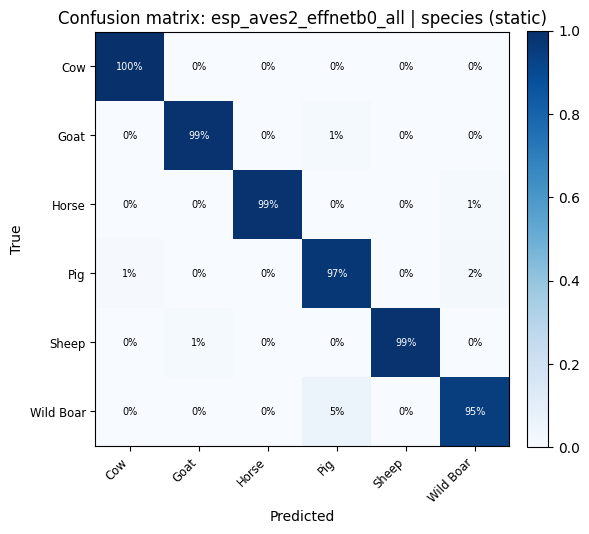

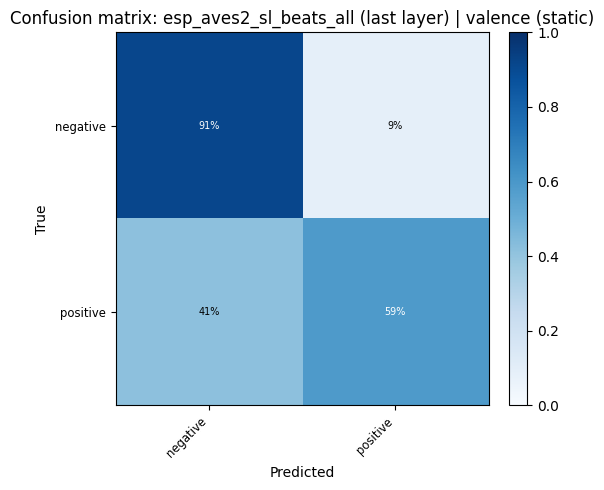

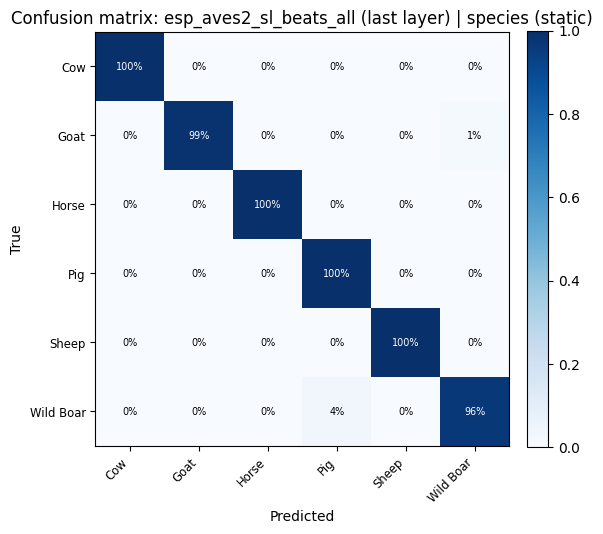

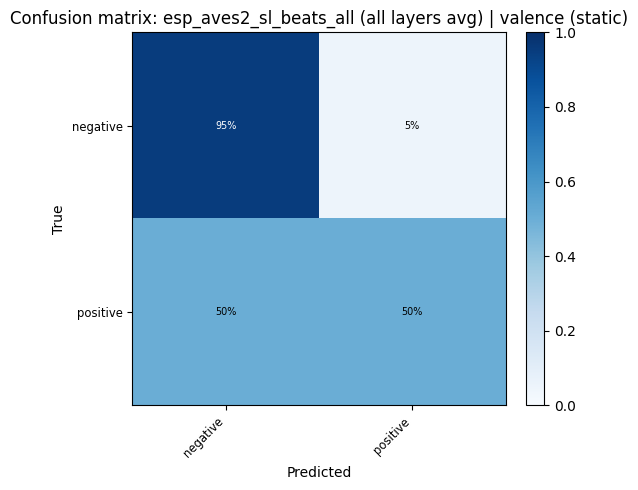

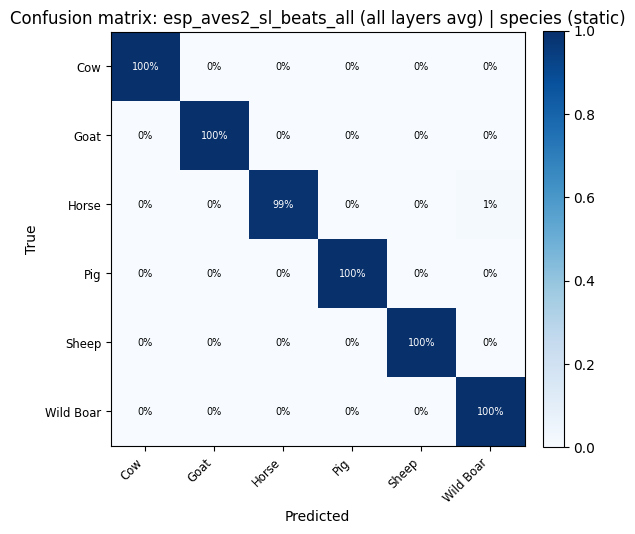

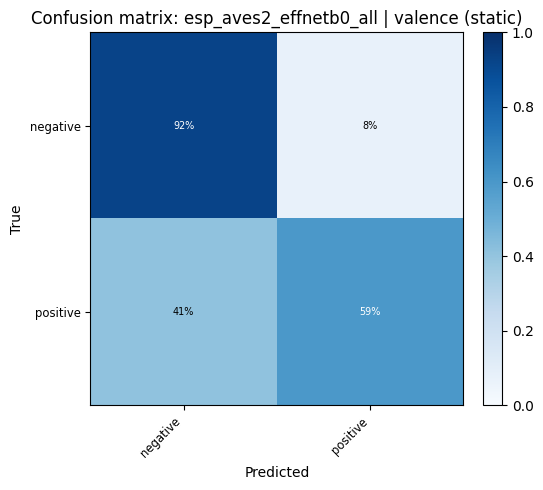

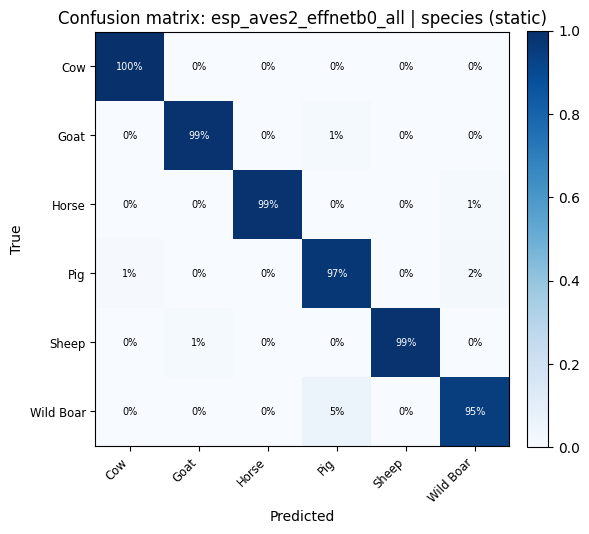

In [18]:
def plot_confusion_matrix(cm: np.ndarray, classes: list, title: str):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    return px.imshow(
        cm_norm,
        x=classes,
        y=classes,
        color_continuous_scale="Blues",
        zmin=0,
        zmax=1,
        text_auto=".2f",
        title=title,
        labels={"x": "Predicted", "y": "True", "color": "Recall"},
        aspect="auto",
    )


for key, res in probe_results.items():
    plot_confusion_matrix(res["confusion_matrix"], res["classes"], title=f"Confusion matrix: {key}").show()
    display(
        confusion_heatmap_static(
            res["confusion_matrix"],
            res["classes"],
            title=f"Confusion matrix: {key} (static)",
        )
    )

## 8. Cross-Species Evaluation (Leave-One-Species-Out)

Train a linear valence probe on **all species except one**, then test on the held-out species.
This measures how well embeddings transfer to an unseen species at inference time — a realistic deployment scenario where not all species are labelled at training time.

In [19]:
def loso_valence_probe(
    embs: np.ndarray,
    species: list[str],
    valence: list[str],
    max_iter: int = 2000,
    random_state: int = 42,
) -> dict[str, dict]:
    """Leave-one-species-out cross-species valence classification.

    For each species S: train LogisticRegression on all other species,
    evaluate on S.  Returns per-species accuracy and test-set size.
    """
    sp_arr = np.array(species)
    val_arr = np.array(valence)
    unique_species = sorted(set(species))
    results = {}
    for test_sp in unique_species:
        train_mask = sp_arr != test_sp
        test_mask = sp_arr == test_sp
        X_train, y_train = embs[train_mask], val_arr[train_mask]
        X_test, y_test = embs[test_mask], val_arr[test_mask]
        if len(np.unique(y_train)) < 2 or len(X_test) == 0:
            results[test_sp] = {"accuracy": float("nan"), "n_test": int(test_mask.sum())}
            continue
        from sklearn.metrics import confusion_matrix
        from sklearn.preprocessing import StandardScaler
        from sklearn.utils import resample

        from utils.probing import _balanced_accuracy_from_confusion_matrix

        # Balance the *training* fold by oversampling minority classes.
        cls_u, cnt_u = np.unique(y_train, return_counts=True)
        max_cnt = int(cnt_u.max())
        x_parts: list[np.ndarray] = []
        y_parts: list[np.ndarray] = []
        for cls in cls_u:
            mask = y_train == cls
            x_c = X_train[mask]
            y_c = y_train[mask]
            if len(x_c) < max_cnt:
                x_c, y_c = resample(
                    x_c,
                    y_c,
                    n_samples=max_cnt,
                    random_state=random_state,
                    replace=True,
                )
            x_parts.append(x_c)
            y_parts.append(y_c)
        X_train = np.vstack(x_parts)
        y_train = np.concatenate(y_parts)

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)
        clf = LogisticRegression(
            max_iter=max_iter,
            random_state=random_state,
            C=1.0,
            solver="lbfgs",
        )
        clf.fit(X_train_sc, y_train)
        y_pred = clf.predict(X_test_sc)
        all_labels = np.array(sorted(set(valence)))
        cm = confusion_matrix(y_test, y_pred, labels=all_labels)
        results[test_sp] = {
            "accuracy": _balanced_accuracy_from_confusion_matrix(cm),
            "n_test": int(test_mask.sum()),
        }
    return results


loso_results: dict[str, dict[str, dict]] = {}
for emb_name, embs in _model_embs:
    print(f"\n--- {emb_name} ---")
    res = loso_valence_probe(embs, species_labels, valence_labels)
    loso_results[emb_name] = res
    for sp, r in res.items():
        acc_str = f"{r['accuracy']:.3f}" if not np.isnan(r["accuracy"]) else "  n/a"
        print(f"  test={sp:<22s}  acc={acc_str}  (n={r['n_test']})")


--- esp_aves2_sl_beats_all (last layer) ---


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  test=Cow                     acc=0.589  (n=1254)
  test=Goat                    acc=0.463  (n=361)
  test=Horse                   acc=0.520  (n=344)
  test=Pig                     acc=0.553  (n=564)
  test=Sheep                   acc=0.507  (n=396)
  test=Wild Boar               acc=0.629  (n=262)


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Model,esp_aves2_effnetb0_all,esp_aves2_sl_beats_all (all layers avg),esp_aves2_sl_beats_all (last layer)
Test species,,,
Cow,0.589,0.520,0.503
Goat,0.463,0.410,0.477
Horse,0.520,0.500,0.479
Pig,0.553,0.568,0.485
Sheep,0.507,0.499,0.552
Wild Boar,0.629,0.554,0.551
Mean,0.544,0.508,0.508


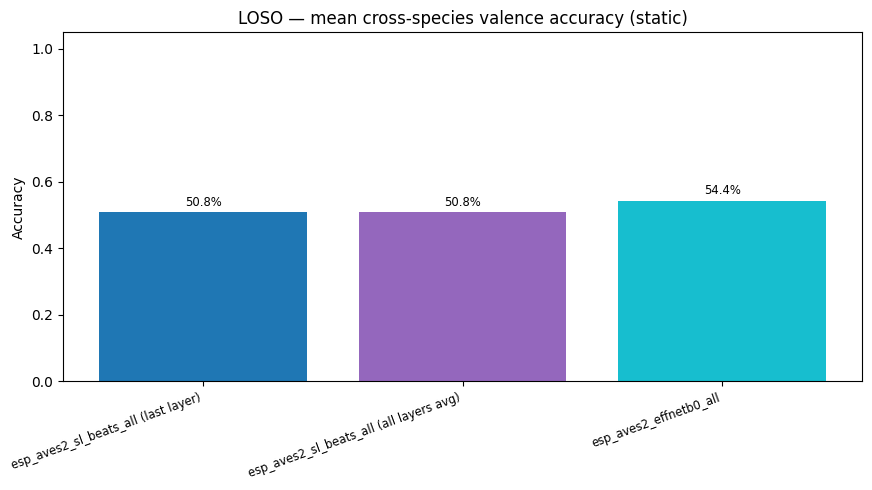

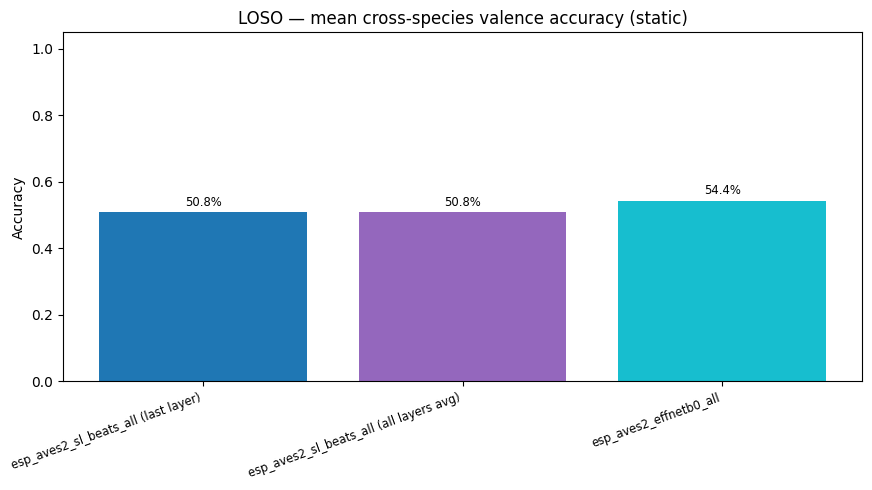

In [20]:
# Summarise LOSO as a heatmap: species (rows) × model (columns)
_loso_rows = []
for emb_name, per_sp in loso_results.items():
    for sp, r in per_sp.items():
        _loso_rows.append({"Model": emb_name, "Test species": sp, "Accuracy": r["accuracy"]})

loso_df = pd.DataFrame(_loso_rows)
loso_pivot = loso_df.pivot(index="Test species", columns="Model", values="Accuracy")

# Append mean row
loso_pivot.loc["Mean"] = loso_pivot.mean()
display(loso_pivot.style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None, vmin=0.4, vmax=1.0))

# Interactive bar chart: per-species LOSO accuracy for each model
fig_loso = px.bar(
    loso_df,
    x="Test species",
    y="Accuracy",
    color="Model",
    barmode="group",
    title="Cross-species valence classification (LOSO) — per held-out species accuracy",
    labels={"Accuracy": "Valence accuracy (test species)"},
    text_auto=".3f",
)
fig_loso.update_layout(yaxis_range=[0, 1])
fig_loso.show()

display(
    plot_model_comparison_static(
        {k: float(np.nanmean([r["accuracy"] for r in v.values()])) for k, v in loso_results.items()},
        title="LOSO — mean cross-species valence accuracy (static)",
    )
)

## Padding Strategy Experiment

For audio clips shorter than 3 s, the choice of padding method can affect how well embeddings capture the vocalization. We compare six strategies for extending clips to a fixed 3-second window:

| Strategy | Description |
|----------|-------------|
| **Pad left** | Silence prepended before the call |
| **Pad right** | Silence appended after the call (current default) |
| **Pad both** | Silence split evenly before and after the call |
| **Pad both + pink noise** | Silence regions filled with low-amplitude pink (1/f) noise |
| **Slow down 2×** | Time-stretched to half speed; any remainder zero-padded right |
| **Slow down 3×** | Time-stretched to one-third speed; any remainder zero-padded right |

Clips already ≥ 3 s are trimmed to 3 s. Only BEATs last-layer embeddings are used for efficiency.

In [ ]:
PAD_TARGET_SAMPLES = int(3.0 * TARGET_SR)
PAD_EXP_EMBED_DIR = EMBED_DIR / "padding_experiment"
PAD_EXP_EMBED_DIR.mkdir(exist_ok=True)

_pad_rng = np.random.default_rng(42)


def _pink_noise(n_samples: int, rng: np.random.Generator) -> np.ndarray:
    """Approximate pink (1/f) noise via FFT spectrum shaping."""
    white = rng.standard_normal(n_samples)
    fft = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(n_samples)
    freqs[0] = 1.0
    fft /= np.sqrt(freqs)
    pink = np.fft.irfft(fft, n=n_samples)
    return (pink / (np.std(pink) + 1e-8) * 0.01).astype(np.float32)


def _pad_audio(wav: np.ndarray, strategy: str, target: int, rng: np.random.Generator) -> np.ndarray:
    """Pad or time-stretch wav to exactly `target` samples."""
    if strategy in ("slowdown_2x", "slowdown_3x"):
        rate = 0.5 if strategy == "slowdown_2x" else 1.0 / 3.0
        stretched = librosa.effects.time_stretch(wav, rate=rate)
        if len(stretched) >= target:
            return stretched[:target]
        return np.pad(stretched, (0, target - len(stretched)))
    clipped = wav[:target]
    n_pad = max(0, target - len(clipped))
    if strategy == "pad_left":
        return np.pad(clipped, (n_pad, 0))
    if strategy == "pad_right":
        return np.pad(clipped, (0, n_pad))
    if strategy == "pad_both":
        left = n_pad // 2
        return np.pad(clipped, (left, n_pad - left))
    if strategy == "pad_both_pink":
        left = n_pad // 2
        noise = _pink_noise(target, rng)
        result = noise.copy()
        result[left : left + len(clipped)] = clipped
        return result
    raise ValueError(f"Unknown strategy: {strategy!r}")


PADDING_STRATEGIES = ["pad_left", "pad_right", "pad_both", "pad_both_pink", "slowdown_2x", "slowdown_3x"]
STRATEGY_LABELS = {
    "pad_left": "Pad left",
    "pad_right": "Pad right",
    "pad_both": "Pad both",
    "pad_both_pink": "Pad both + pink noise",
    "slowdown_2x": "Slow 2×",
    "slowdown_3x": "Slow 3×",
}

padding_embs: dict[str, np.ndarray] = {}
_pad_model = None

for _strategy in PADDING_STRATEGIES:
    _cache = PAD_EXP_EMBED_DIR / f"beats_last_{_strategy}.npy"
    if _cache.exists():
        _arr = np.load(_cache)
        if _arr.shape[0] == len(df):
            padding_embs[_strategy] = _arr
            print(f"Loaded  '{_strategy}': {padding_embs[_strategy].shape}")
            continue

    # Recompute embeddings (inference only; no training)
    if _pad_model is None:
        print(f"Loading {BEATS_MODEL} ...")
        _pad_model = load_model(BEATS_MODEL, return_features_only=True, device=DEVICE)
        _pad_model.eval()

    _embeddings = []
    with torch.no_grad():
        for _path in tqdm(df["path"], desc=f"BEATs ({_strategy})"):
            _wav, _ = librosa.load(_path, sr=TARGET_SR, mono=True)
            _wav = _pad_audio(_wav, _strategy, PAD_TARGET_SAMPLES, _pad_rng)
            _tensor = torch.from_numpy(_wav).unsqueeze(0).to(DEVICE)
            _feats = _pad_model(_tensor)
            _embeddings.append(_feats.mean(dim=1).squeeze(0).cpu().numpy())

    padding_embs[_strategy] = np.stack(_embeddings)
    np.save(_cache, padding_embs[_strategy])
    print(f"Saved   '{_strategy}': {padding_embs[_strategy].shape}")

if _pad_model is not None:
    del _pad_model

In [22]:
if not padding_embs:
    print("Skipping padding probes: no cached embeddings.")
else:
    pad_probe_results: dict[str, dict] = {}
    for _strategy, _embs in padding_embs.items():
        for _task, _task_labels in [("valence", valence_labels), ("species", species_labels)]:
            _key = f"{_strategy} | {_task}"
            _res = run_linear_probe(_embs, _task_labels, **probe_kwargs)
            pad_probe_results[_key] = _res
            print(f"{STRATEGY_LABELS[_strategy]:<24s} | {_task:<14s}: {_res['accuracy']:.3f}")

Skipping padding probes: no cached embeddings.


In [23]:
if not globals().get("pad_probe_results"):
    print("Skipping padding viz: no results.")
else:
    _pad_rows = []
    for _key, _res in pad_probe_results.items():
        _strategy, _task = _key.split(" | ")
        _pad_rows.append(
            {"Strategy": STRATEGY_LABELS[_strategy], "Task": _task, "Accuracy": round(_res["accuracy"], 4)}
        )
    pad_df = pd.DataFrame(_pad_rows)
    display(pad_df.pivot(index="Strategy", columns="Task", values="Accuracy").style.format("{:.4f}"))

    fig_pad = px.bar(
        pad_df,
        x="Strategy",
        y="Accuracy",
        color="Task",
        barmode="group",
        title="Padding strategy comparison — BEATs last layer, 3-second window",
        labels={"Strategy": "Padding strategy", "Accuracy": "Linear probe accuracy"},
        text_auto=".3f",
    )
    fig_pad.update_layout(yaxis_range=[0, 1], xaxis_tickangle=-20)
    fig_pad.show()

    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    fig_pad.write_html(str(ARTIFACTS_DIR / "padding_strategy_comparison.html"))

    for _task in sorted(pad_df["Task"].unique()):
        _task_dict = {row["Strategy"]: row["Accuracy"] for _, row in pad_df[pad_df["Task"] == _task].iterrows()}
        _static = plot_model_comparison_static(_task_dict, title=f"Padding strategy — {_task} (static)")
        display(_static)
        _static.savefig(str(ARTIFACTS_DIR / f"padding_strategy_{_task}_static.png"), dpi=150, bbox_inches="tight")
        plt.close()
    print("Padding experiment figures saved.")

Skipping padding viz: no results.


## 9. Save Artifacts

In [24]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Save interactive HTML figures
for name, fig in umap_valence_figs.items():
    slug = name.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "-")
    fig.write_html(str(ARTIFACTS_DIR / f"umap_valence_{slug}.html"))

for name, fig in umap_species_figs.items():
    slug = name.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "-")
    fig.write_html(str(ARTIFACTS_DIR / f"umap_species_{slug}.html"))

fig_cmp_valence.write_html(str(ARTIFACTS_DIR / "model_comparison_valence.html"))
fig_cmp_species.write_html(str(ARTIFACTS_DIR / "model_comparison_species.html"))
fig_loso.write_html(str(ARTIFACTS_DIR / "loso_cross_species.html"))

# Save static PNG figures
for name, fig in umap_valence_static_figs.items():
    slug = name.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "-")
    fig.savefig(str(ARTIFACTS_DIR / f"umap_valence_{slug}.png"), dpi=150, bbox_inches="tight")

for name, fig in umap_species_static_figs.items():
    slug = name.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "-")
    fig.savefig(str(ARTIFACTS_DIR / f"umap_species_{slug}.png"), dpi=150, bbox_inches="tight")

plt.close("all")

# Save metrics JSON
_metrics_out = {
    "n_calls": len(df),
    "n_species": df["species"].nunique(),
    "species": sorted(df["species"].unique().tolist()),
    "valence_counts": df["valence"].value_counts().to_dict(),
    "training_free": {k: v for k, v in tf_results.items()},
    "linear_probe_accuracy": {k: round(v["accuracy"], 4) for k, v in probe_results.items()},
    "attention_probe_accuracy": {k: round(v["accuracy"], 4) for k, v in attention_results.items()},
    "loso_cross_species": {
        emb_name: {sp: round(r["accuracy"], 4) for sp, r in per_sp.items()} for emb_name, per_sp in loso_results.items()
    },
    "loso_cross_species_mean": {
        emb_name: round(float(np.nanmean([r["accuracy"] for r in per_sp.values()])), 4)
        for emb_name, per_sp in loso_results.items()
    },
}
with open(ARTIFACTS_DIR / "ungulate_metrics.json", "w") as _f:
    json.dump(_metrics_out, _f, indent=2, default=float)

print(f"Artifacts saved to {ARTIFACTS_DIR}")
print("  annotations.csv (raw annotations from Excel)")
print("  ungulate_metrics.json")
print(f"  {len(umap_valence_figs) + len(umap_species_figs)} UMAP HTML + PNG files")
print("  model_comparison_valence.html / _species.html")
print("  loso_cross_species.html")

Artifacts saved to /home/marius_miron_earthspecies_org/code/avex-examples/examples/09_ungulate_valence/artifacts
  annotations.csv (raw annotations from Excel)
  ungulate_metrics.json
  6 UMAP HTML + PNG files
  model_comparison_valence.html / _species.html
  loso_cross_species.html
